In [2]:
import numpy as np
import json
from imageio.v2 import imread

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')

from holodoppler.propagation import fresnel_transform_noshift as fresnel_transform, angular_spectrum_transform
from holodoppler.moments import moment
from holodoppler.filtering import frequency_symmetric_filtering

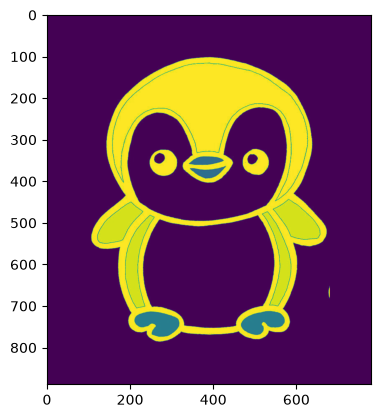

In [4]:
%matplotlib inline
img = imread("../debug_outputs/penguin.png")

img = 255-np.mean(img, axis=-1)
img = img.astype(np.uint8)

# plt.imshow(img)
# plt.show()

img = np.pad(img, ((100,100),(100,100)))

plt.imshow(img)
plt.show()

img = img[np.newaxis, ...]

In [ ]:
z = 0.5
wavelength = 852e-9
pixel_pitch = (20e-6,20e-6)
def retrieve_hologram(xp, objective_amplitude, num_iteration=25, z=0.5, 
                      wavelength=852e-9, pixel_pitch=(20e-6, 20e-6),
                      hologram_type='phase'):  # 'phase', 'amplitude', 'binary'
    
    _, ny, nx = objective_amplitude.shape
    
    # Initial guess
    phase = 2 * xp.pi * xp.random.rand(ny, nx)
    hologram_guess = xp.exp(1j * phase)
    hologram_guess = hologram_guess[np.newaxis, ...]
    
    for k in range(num_iteration):
        # Forward propagation
        imgk = angular_spectrum_transform(xp, xp.fft, hologram_guess, z, pixel_pitch, wavelength)
        
        # Enforce image plane constraint
        imgk = objective_amplitude * xp.exp(1j * xp.angle(imgk))
        
        # Backward propagation
        hologram_guess = angular_spectrum_transform(xp, xp.fft, imgk, -z, pixel_pitch, wavelength)
        
        # Enforce hologram constraint
        if hologram_type == 'phase':
            hologram_guess = xp.exp(1j * xp.angle(hologram_guess))
        elif hologram_type == 'amplitude':
            hologram_guess = xp.abs(hologram_guess) * xp.exp(1j * 0)  # Set phase to 0
        elif hologram_type == 'binary':
            hologram_guess = xp.where(xp.abs(hologram_guess) > 0.5, 1.0, 0.0)
    
    return hologram_guess

# Get phase-only hologram
hologram_complex = retrieve_hologram(np, img, hologram_type='phase')

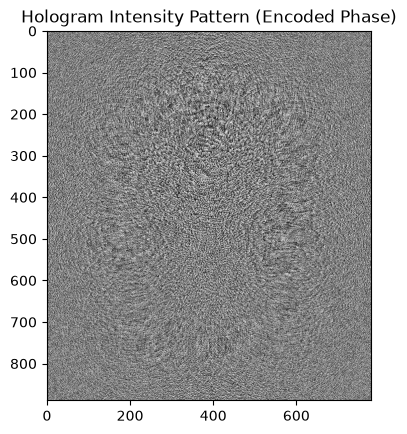

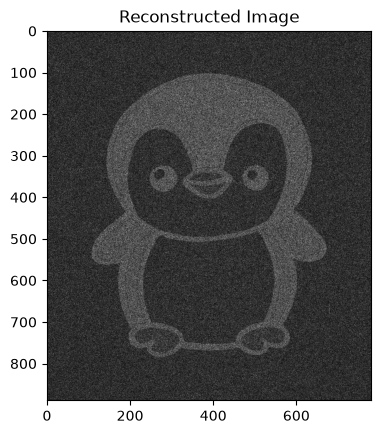

In [7]:
# The "intensity" pattern you can display/print:
hologram_angle = np.angle(hologram_complex[0])  # Phase values 0 to 2π

intensity_display = ((hologram_angle + np.pi) / (2 * np.pi) * 255).astype(np.uint8)

plt.imshow(intensity_display, cmap='gray')
plt.title('Hologram Intensity Pattern (Encoded Phase)')
plt.show()

# Reconstruct to verify
reconstructed = angular_spectrum_transform(np, np.fft, hologram_angle, z, pixel_pitch, wavelength)
plt.imshow(np.abs(reconstructed[0]), cmap='gray')
plt.title('Reconstructed Image')
plt.show()

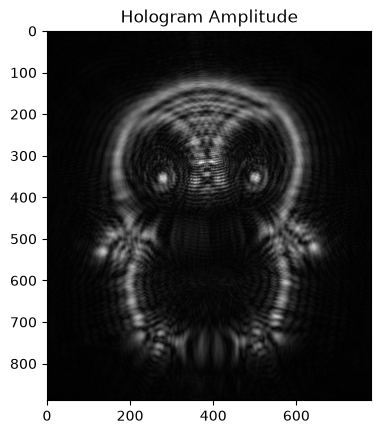

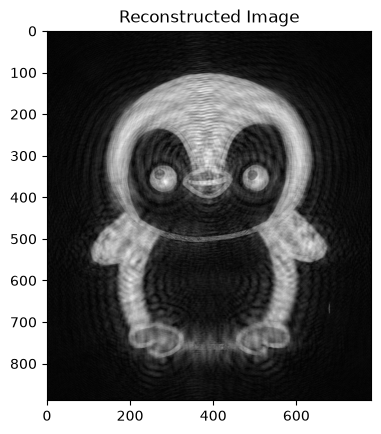

In [10]:
# Get amp-only hologram
hologram_complex = retrieve_hologram(np, img, hologram_type='amplitude')

hologram_amp = np.abs(hologram_complex)

plt.imshow(hologram_amp[0], cmap='gray')
plt.title('Hologram Amplitude')
plt.show()

reconstructed = angular_spectrum_transform(np, np.fft, hologram_amp, z, pixel_pitch, wavelength)
plt.imshow(np.abs(reconstructed[0]), cmap='gray')
plt.title('Reconstructed Image')
plt.show()

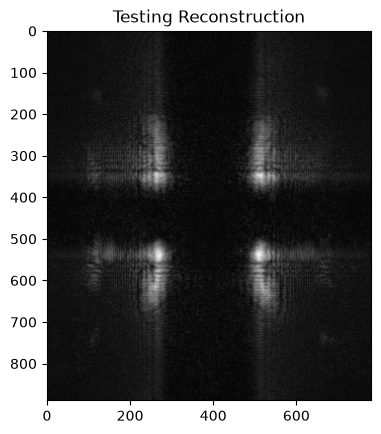

In [13]:
z = 0.5
wavelength = 852e-9
pixel_pitch = (20e-6,20e-6)
def retrieve_hologram_fresnel(xp, objective_amplitude, num_iteration=25, z=0.5, 
                      wavelength=852e-9, pixel_pitch=(20e-6, 20e-6),
                      hologram_type='phase'):  # 'phase', 'amplitude', 'binary'
    
    _, ny, nx = objective_amplitude.shape
    
    # Initial guess
    phase = 2 * xp.pi * xp.random.rand(ny, nx)
    hologram_guess = xp.exp(1j * phase)
    hologram_guess = hologram_guess[np.newaxis, ...]
    
    for k in range(num_iteration):
        # Forward propagation
        imgk = fresnel_transform(xp, xp.fft, hologram_guess, z, pixel_pitch, wavelength)
        
        # Enforce image plane constraint
        imgk = objective_amplitude * xp.exp(1j * xp.angle(imgk))
        
        # Backward propagation
        hologram_guess = fresnel_transform(xp, xp.fft, imgk, -z, pixel_pitch, wavelength)
        
        # Enforce hologram constraint
        if hologram_type == 'phase':
            hologram_guess = xp.exp(1j * xp.angle(hologram_guess))
        elif hologram_type == 'amplitude':
            hologram_guess = xp.abs(hologram_guess)
        elif hologram_type == 'binary':
            hologram_guess = xp.where(xp.abs(hologram_guess) > 0.5, 1.0, 0.0)
    
    return hologram_guess

# Get phase-only hologram
hologram_complex = retrieve_hologram_fresnel(np, img, hologram_type='amplitude')

# testing 
img_test = fresnel_transform(np, np.fft, hologram_complex, z, pixel_pitch, wavelength)

plt.imshow(np.abs(img_test)[0], cmap='gray')
plt.title('Testing Reconstruction')
plt.show()

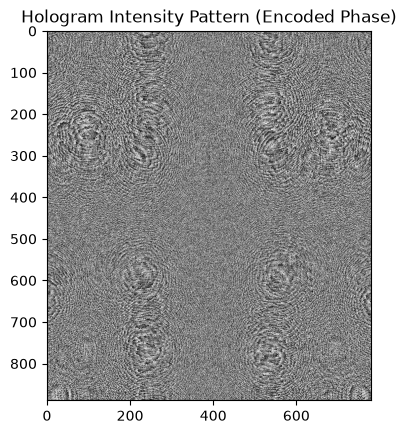

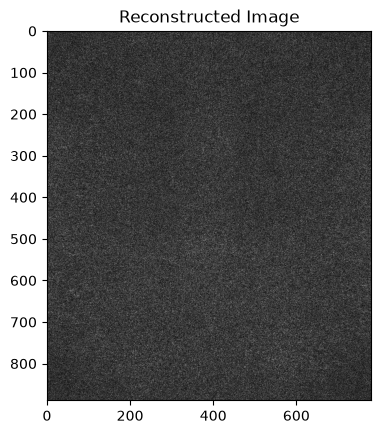

In [9]:
# The "intensity" pattern you can display/print:
hologram_angle = np.angle(hologram_complex[0])  # Phase values 0 to 2π

intensity_display = ((hologram_angle + np.pi) / (2 * np.pi) * 255).astype(np.uint8)

plt.imshow(intensity_display, cmap='gray')
plt.title('Hologram Intensity Pattern (Encoded Phase)')
plt.show()

# Reconstruct to verify
reconstructed = fresnel_transform(np, np.fft, hologram_angle, z, pixel_pitch, wavelength)
plt.imshow(np.abs(reconstructed[0]), cmap='gray')
plt.title('Reconstructed Image')
plt.show()

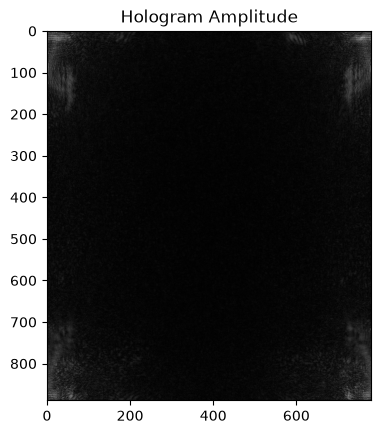

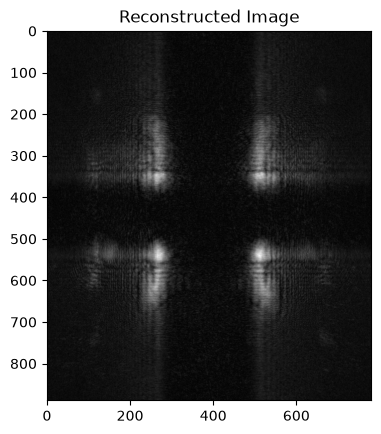

In [10]:
# Get amp-only hologram
hologram_complex = retrieve_hologram_fresnel(np, img, hologram_type='amplitude')

hologram_amp = np.abs(hologram_complex)

plt.imshow(hologram_amp[0], cmap='gray')
plt.title('Hologram Amplitude')
plt.show()

reconstructed = fresnel_transform(np, np.fft, hologram_amp, z, pixel_pitch, wavelength)
plt.imshow(np.abs(reconstructed[0]), cmap='gray')
plt.title('Reconstructed Image')
plt.show()